In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("hotel_bookings.csv")


In [2]:
# Handle missing values
df['children'] = df['children'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)



In [3]:
# Convert dates
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')


In [4]:
# Remove duplicates
df = df.drop_duplicates()


**`** Basic Questions**`**

In [5]:
# 1. Average lead time
print("Average Lead Time:", df['lead_time'].mean())

Average Lead Time: 79.89136802599661


In [6]:
# 2. Distribution of bookings by hotel type
print("Bookings by Hotel Type:\n", df['hotel'].value_counts())


Bookings by Hotel Type:
 hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


In [7]:
# 3. Total cancellations
print("Total Cancellations:", df['is_canceled'].sum())


Total Cancellations: 24025


In [8]:
# 4. Most common arrival month
print("Most Common Arrival Month:", df['arrival_date_month'].mode()[0])


Most Common Arrival Month: August


In [9]:
# 5. Average number of special requests
print("Average Special Requests:", df['total_of_special_requests'].mean())


Average Special Requests: 0.6985674401574443


In [10]:
# 6. Country with highest number of bookings
print("Top Country:", df['country'].value_counts().idxmax())


Top Country: PRT


In [11]:
# 7. Average ADR for each hotel type
print("Avg ADR per Hotel:\n", df.groupby('hotel')['adr'].mean())


Avg ADR per Hotel:
 hotel
City Hotel      110.985944
Resort Hotel     99.025346
Name: adr, dtype: float64


In [12]:
# 8. Percentage of guests requiring car parking
print("% Guests needing Parking:", (df['required_car_parking_spaces']>0).mean()*100)

% Guests needing Parking: 8.367659847132591


In [13]:
# 9. Average stay duration (week nights & weekend nights)
print("Avg Week Nights:", df['stays_in_week_nights'].mean())
print("Avg Weekend Nights:", df['stays_in_weekend_nights'].mean())

Avg Week Nights: 2.6253947549086916
Avg Weekend Nights: 1.005263398782553


In [14]:
# 10. Bookings made through travel agents
print("Bookings via Agents:", df['agent'].astype(bool).sum())

Bookings via Agents: 75203


**` Medium Questions`**

In [15]:
# 1. Cancellation rate for each hotel type
print("Cancellation Rate per Hotel:\n", df.groupby('hotel')['is_canceled'].mean())

Cancellation Rate per Hotel:
 hotel
City Hotel      0.300386
Resort Hotel    0.234809
Name: is_canceled, dtype: float64


In [16]:
# 2. Average ADR per market segment
print("Avg ADR per Market Segment:\n", df.groupby('market_segment')['adr'].mean())

Avg ADR per Market Segment:
 market_segment
Aviation         100.170396
Complementary      3.049245
Corporate         68.151246
Direct           116.579429
Groups            74.864284
Offline TA/TO     81.764191
Online TA        118.171606
Undefined         15.000000
Name: adr, dtype: float64


In [17]:
# 3. Relationship between lead time and cancellation
print("Correlation Lead Time vs Cancellation:", df['lead_time'].corr(df['is_canceled']))

Correlation Lead Time vs Cancellation: 0.18480558777334238


In [18]:
# 4. Distribution channel with highest bookings
print("Bookings per Distribution Channel:\n", df['distribution_channel'].value_counts())

Bookings per Distribution Channel:
 distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64


In [19]:
# 5. Average previous cancellations by hotel type
print("Avg Previous Cancellations per Hotel:\n", df.groupby('hotel')['previous_cancellations'].mean())

Avg Previous Cancellations per Hotel:
 hotel
City Hotel      0.035768
Resort Hotel    0.021991
Name: previous_cancellations, dtype: float64


In [20]:
# 6. Trend of ADR over the years
print("ADR Trend per Year:\n", df.groupby('arrival_date_year')['adr'].mean())

ADR Trend per Year:
 arrival_date_year
2015     92.160752
2016    101.538903
2017    118.710660
Name: adr, dtype: float64


In [21]:
# 7. Month with highest revenue
print("Highest Revenue Month:\n", df.groupby('arrival_date_month')['adr'].sum().sort_values(ascending=False).head(1))

Highest Revenue Month:
 arrival_date_month
August    1698412.48
Name: adr, dtype: float64


In [22]:
# 8. Impact of special requests on ADR
print("Correlation Special Requests vs ADR:", df['total_of_special_requests'].corr(df['adr']))

Correlation Special Requests vs ADR: 0.13783120378843688


In [23]:
# 9. Average stay duration for repeated vs new guests
print("Avg Stay Duration (Repeated vs New):\n",
      df.groupby('is_repeated_guest')[['stays_in_week_nights','stays_in_weekend_nights']].mean())

Avg Stay Duration (Repeated vs New):
                    stays_in_week_nights  stays_in_weekend_nights
is_repeated_guest                                               
0                              2.672414                 1.027518
1                              1.469107                 0.457980


In [24]:
# 10. Room type with highest number of bookings
print("Most Booked Room Type:", df['reserved_room_type'].value_counts().idxmax())

Most Booked Room Type: A


**Advanced Questions**

In [25]:
# 1. Factors significantly impacting cancellation rate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['lead_time','booking_changes','total_of_special_requests']].fillna(0)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
model = LogisticRegression(max_iter=500).fit(X_train,y_train)

print("Top predictors of cancellation (coefficients):")
print(pd.DataFrame({'Feature':X.columns,'Coefficient':model.coef_[0]}))

Top predictors of cancellation (coefficients):
                     Feature  Coefficient
0                  lead_time     0.004948
1            booking_changes    -0.499039
2  total_of_special_requests    -0.379926


In [26]:
# 2. ADR variation with adults, children, babies
print("ADR vs Adults correlation:", df['adr'].corr(df['adults']))
print("ADR vs Children correlation:", df['adr'].corr(df['children']))
print("ADR vs Babies correlation:", df['adr'].corr(df['babies']))

ADR vs Adults correlation: 0.24899934124007156
ADR vs Children correlation: 0.32629256959465824
ADR vs Babies correlation: 0.0234455982897137


In [27]:
# 3. Impact of booking changes on special requests
print("Correlation between booking_changes and special_requests:",
      df['booking_changes'].corr(df['total_of_special_requests']))

Correlation between booking_changes and special_requests: 0.0161150007466844


In [28]:
# 4. Seasonal impact on cancellations
print("Cancellation rate per month:\n",
      df.groupby('arrival_date_month')['is_canceled'].mean())

Cancellation rate per month:
 arrival_date_month
April        0.304628
August       0.321844
December     0.268564
February     0.232043
January      0.221180
July         0.317987
June         0.303155
March        0.243578
May          0.292280
November     0.211011
October      0.236804
September    0.245441
Name: is_canceled, dtype: float64


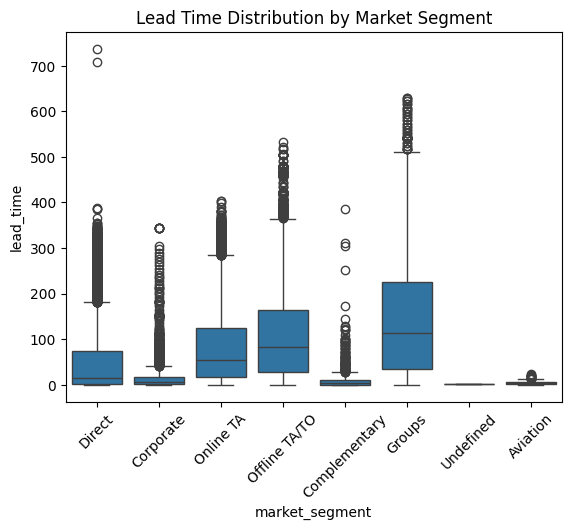

In [29]:
# 5. Lead time distribution by market segment
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='market_segment', y='lead_time', data=df)
plt.xticks(rotation=45)
plt.title("Lead Time Distribution by Market Segment")
plt.show()

**Additional Considerations**

- Ethical & Privacy: Protect guest data, anonymize sensitive fields, ensure compliance with GDPR.
- Interdisciplinary Collaboration: Work with hotel managers, marketing, and operations teams to validate insights.
- Continuous Improvement: Update dashboards regularly, refine models with new booking data.


**Deliverables**

- Case Study Document → Problem statement, dataset, cleaning, Q&A.
- Solution Guide → Python notebook + Tableau dashboard with visuals.
- Insights Report →
- Resort vs City hotel booking trends.
- Cancellation drivers (lead time, booking changes).
- Market segment ADR differences.
- Seasonal peaks in revenue and cancellations.
- Additional Resources → Kaggle dataset, references for EDA best practices.


**Desired Outcome**

- Develop analytical mindset for hospitality data.
- Provide decision support for management and operations.
- Understand guest preferences and booking behavior.
- Align business strategy with booking trends, cancellations, and ADR.
- Benchmark occupancy and revenue metrics.
- Continuously improve analysis with updated data.
